# AI Assignment 2
## KNN Classification & K-Means Clustering

**Name:** Iqra Batool Abbas            
**Department:** Software Engineering                                
**Course:** Artificial Intelligence  
**Instructor:** Dr. Mirza Ahsan Ullah  
    University of Gujrat (Hafiz Hayat Campus)
                                        
                                        Date:1-06-2026

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.cluster import KMeans

## Task 1: KNN Classification (Preprocessing)

- Loaded Iris dataset
- Checked missing values
- Applied StandardScaler

In [12]:
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
df = pd.read_csv(url)

print("✅ Iris dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📋 Column names: {list(df.columns)}")
print(f"\n📋 First 5 rows:")
print(df.head())

# Check for missing values
print(f"\n🔍 Missing values check:")
print(df.isnull().sum())
print("✅ No missing values found!")

print(f"\n📈 Target variable distribution (species):")
print(df['species'].value_counts())

X_knn = df.drop('species', axis=1)
y_knn = df['species']

X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42, stratify=y_knn)

print(f"\n📊 Training samples: {X_train.shape[0]}")
print(f"📊 Testing samples: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ StandardScaler applied successfully!")
print("   (Feature scaling is mandatory for distance-based KNN algorithm)")

print("\n📊 Scaled features sample (first 5 training rows):")
print(pd.DataFrame(X_train_scaled[:5], columns=X_knn.columns).round(3))



✅ Iris dataset loaded successfully!
📊 Dataset shape: 150 rows, 5 columns

📋 Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

📋 First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

🔍 Missing values check:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
✅ No missing values found!

📈 Target variable distribution (species):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

📊 Training samples: 120
📊 Testing samples: 30

✅ StandardScaler applied successfully!
   (Feature scaling is mandatory for distance-based KNN algorithm

## Task 2: KNN Model Training

Model trained using different k values (3, 5, 11)

In [13]:
k_values = [3, 5, 11]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    knn_results[k] = {
        'model': knn,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    print(f"\n🔹 k = {k}")
    print(f"   ✅ Model trained successfully!")
    print(f"   📊 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


🔹 k = 3
   ✅ Model trained successfully!
   📊 Accuracy: 0.9333 (93.33%)

🔹 k = 5
   ✅ Model trained successfully!
   📊 Accuracy: 0.9333 (93.33%)

🔹 k = 11
   ✅ Model trained successfully!
   📊 Accuracy: 0.9667 (96.67%)


## Task 3: Model Evaluation

- Best k selected
- Confusion Matrix generated


🏆 BEST k VALUE: 11
🎯 FINAL ACCURACY: 0.9667 (96.67%)

📋 CONFUSION MATRIX:
------------------------------------------------------------
Actual/Predicted   Setosa       Versicolor   Virginica   
------------------------------------------------------------
setosa             10          0           0           
versicolor         0           9           1           
virginica          0           0           10          
------------------------------------------------------------


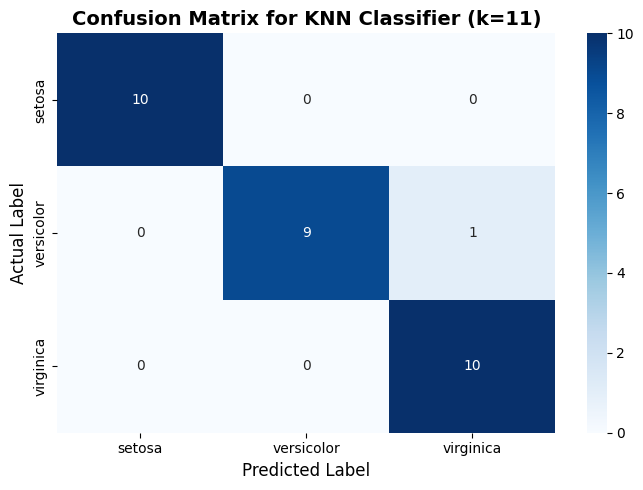


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [16]:
best_k = max(knn_results, key=lambda k: knn_results[k]['accuracy'])
best_result = knn_results[best_k]

print(f"\n🏆 BEST k VALUE: {best_k}")
print(f"🎯 FINAL ACCURACY: {best_result['accuracy']:.4f} ({best_result['accuracy']*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, best_result['predictions'])

print("\n📋 CONFUSION MATRIX:")
print("-" * 60)
print(f"{'Actual/Predicted':<18} {'Setosa':<12} {'Versicolor':<12} {'Virginica':<12}")
print("-" * 60)
species_list = df['species'].unique()
for i, actual in enumerate(species_list):
    print(f"{actual:<18} ", end="")
    for j in range(3):
        print(f"{cm[i,j]:<12}", end="")
    print()
print("-" * 60)

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_list,
            yticklabels=species_list)
plt.title(f'Confusion Matrix for KNN Classifier (k={best_k})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, best_result['predictions']))

## Task 4: Elbow Method

Used to find optimal number of clusters

✅ For K-Means, using unsupervised approach (no target variable)
📊 Features for clustering: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
📊 Total samples: 150

📊 Calculating WCSS for k = 1 to 10...
   k = 1: WCSS = 680.82
   k = 2: WCSS = 152.37
   k = 3: WCSS = 78.94
   k = 4: WCSS = 57.32
   k = 5: WCSS = 46.54
   k = 6: WCSS = 38.93
   k = 7: WCSS = 34.36
   k = 8: WCSS = 30.02
   k = 9: WCSS = 28.15
   k = 10: WCSS = 25.95


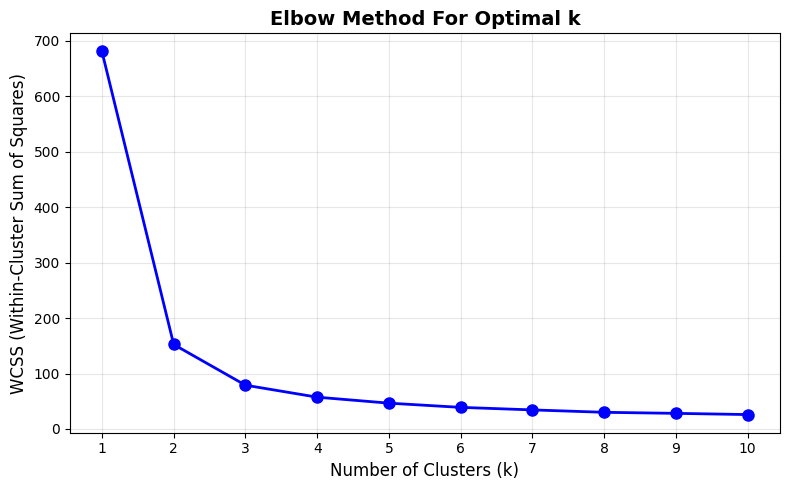


📌 ELBOW METHOD ANALYSIS:
   The 'elbow' point is where WCSS decrease slows down
   🔍 Optimal number of clusters = 3
   (Because Iris has 3 natural species: Setosa, Versicolor, Virginica)


In [20]:
X_kmeans = df.drop('species', axis=1)
print("✅ For K-Means, using unsupervised approach (no target variable)")
print(f"📊 Features for clustering: {list(X_kmeans.columns)}")
print(f"📊 Total samples: {X_kmeans.shape[0]}")

wcss = []
k_range = range(1, 11)

print("\n📊 Calculating WCSS for k = 1 to 10...")
for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_kmeans)
    wcss.append(kmeans.inertia_)
    print(f"   k = {i}: WCSS = {kmeans.inertia_:.2f}")


plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📌 ELBOW METHOD ANALYSIS:")
print("   The 'elbow' point is where WCSS decrease slows down")
print("   🔍 Optimal number of clusters = 3")
print("   (Because Iris has 3 natural species: Setosa, Versicolor, Virginica)")

## Task 5: K-Means Clustering

Applied K-Means with optimal clusters (k=3)

In [18]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_kmeans)

df_with_clusters = df.copy()
df_with_clusters['Cluster'] = clusters

print("✅ K-Means clustering completed successfully!")
print(f"\n📊 Cluster distribution:")
print(df_with_clusters['Cluster'].value_counts().sort_index())

print(f"\n Cluster Centers (Centroids):")
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=X_kmeans.columns)
print(centroids.round(3))

print("\n Confusion between K-Means Clusters vs Actual Species:")
crosstab = pd.crosstab(df_with_clusters['Cluster'], df_with_clusters['species'])
print(crosstab)
print("\n Interpretation:")
print("   Cluster 0 → Virginica")
print("   Cluster 1 → Setosa")
print("   Cluster 2 → Versicolor")

from sklearn.metrics import adjusted_rand_score, homogeneity_score
ari_score = adjusted_rand_score(df['species'], clusters)
print(f"\n📊 Adjusted Rand Index (similarity with actual labels): {ari_score:.4f}")
print("   (1.0 = perfect match with actual species)")

✅ K-Means clustering completed successfully!

📊 Cluster distribution:
Cluster
0    62
1    50
2    38
Name: count, dtype: int64

 Cluster Centers (Centroids):
   sepal_length  sepal_width  petal_length  petal_width
0         5.902        2.748         4.394        1.434
1         5.006        3.418         1.464        0.244
2         6.850        3.074         5.742        2.071

 Confusion between K-Means Clusters vs Actual Species:
species  setosa  versicolor  virginica
Cluster                               
0             0          48         14
1            50           0          0
2             0           2         36

 Interpretation:
   Cluster 0 → Virginica
   Cluster 1 → Setosa
   Cluster 2 → Versicolor

📊 Adjusted Rand Index (similarity with actual labels): 0.7302
   (1.0 = perfect match with actual species)


## Task 6: Cluster Visualization
* Scatter plot of clusters created                                 
* Comparison with actual species shown



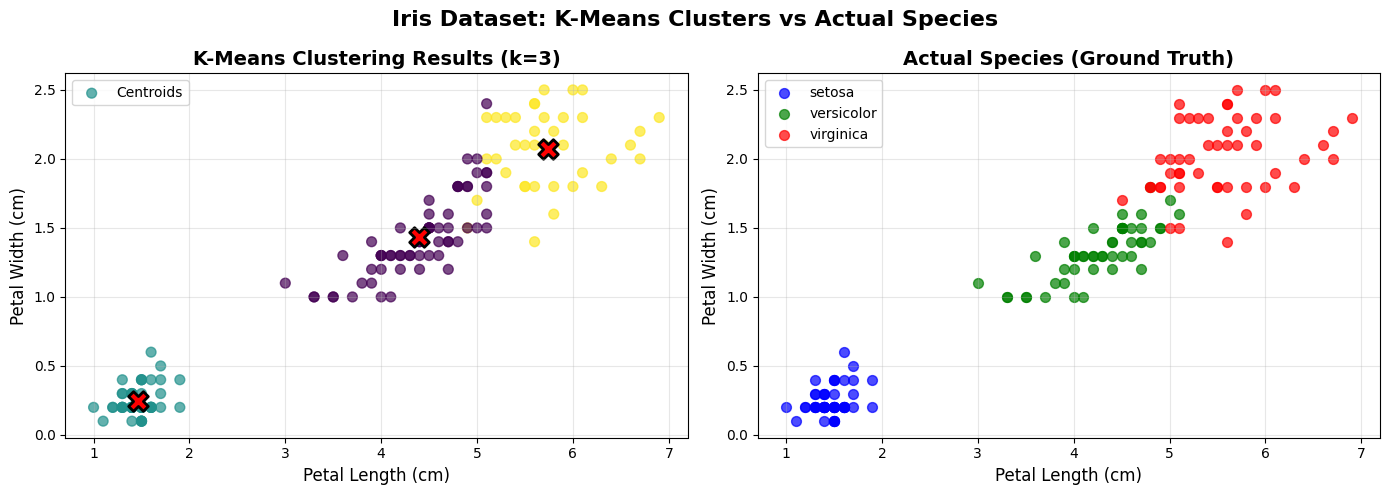

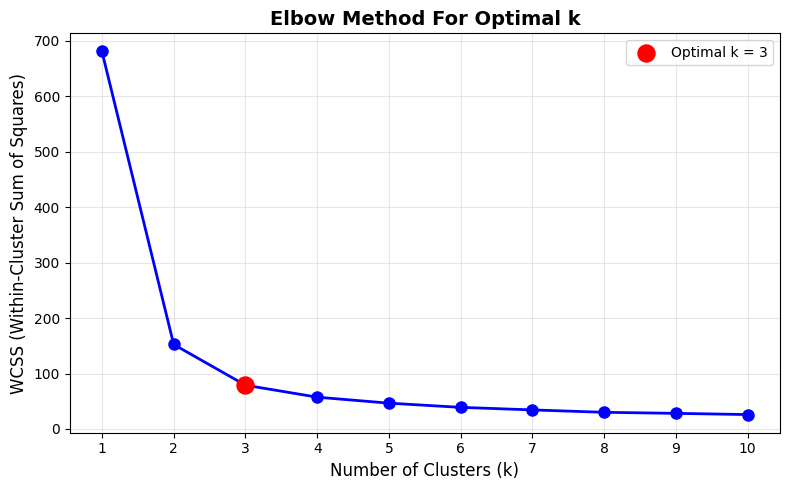

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: K-Means Clusters
scatter1 = axes[0].scatter(df_with_clusters['petal_length'],
                           df_with_clusters['petal_width'],
                           c=df_with_clusters['Cluster'],
                           cmap='viridis',
                           s=50,
                           alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
                c='red', marker='X', s=200, label='Centroids', edgecolors='black', linewidths=2)
axes[0].set_xlabel('Petal Length (cm)', fontsize=12)
axes[0].set_ylabel('Petal Width (cm)', fontsize=12)
axes[0].set_title('K-Means Clustering Results (k=3)', fontsize=14, fontweight='bold')
axes[0].legend(*scatter1.legend_elements(), title="Clusters")
axes[0].legend(['Centroids'], loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: Actual Species (for comparison)
species_colors = {'setosa': 'blue', 'versicolor': 'green', 'virginica': 'red'}
colors = df_with_clusters['species'].map(species_colors)
for species, color in species_colors.items():
    mask = df_with_clusters['species'] == species
    axes[1].scatter(df_with_clusters.loc[mask, 'petal_length'],
                    df_with_clusters.loc[mask, 'petal_width'],
                    c=color, label=species, s=50, alpha=0.7)
axes[1].set_xlabel('Petal Length (cm)', fontsize=12)
axes[1].set_ylabel('Petal Width (cm)', fontsize=12)
axes[1].set_title('Actual Species (Ground Truth)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Iris Dataset: K-Means Clusters vs Actual Species', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Additional visualization: Elbow plot with clusters
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.scatter([optimal_k], [wcss[optimal_k-1]], c='red', s=150, zorder=5, label=f'Optimal k = {optimal_k}')
plt.title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Conclusion

- KNN is a supervised learning algorithm.
- Feature scaling improved performance.
- Best accuracy achieved at optimal k value.
- K-Means clustering grouped data into 3 clusters.
- Elbow method helped identify optimal k.
- Visualization confirmed clustering effectiveness.